# Хакатон: Анализ сайта СберАвтоподписки
## Notebook 3: Построение ML-модели

В этом ноутбуке я строю модель машинного обучения, которая предсказывает вероятность совершения целевого действия пользователем на сайте. Цель по метрике — ROC-AUC не ниже 0.65.

### 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier, Pool
import shap

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_PATH = r'D:\sber-autosubscription-hackathon'

print('Загружаю данные...')
sessions = pd.read_pickle(f'{DATA_PATH}\\sessions_eda.pkl')
print(f'Загружено: {sessions.shape[0]:,} строк, {sessions.shape[1]} колонок')
print('Данные загружены.')

Загружаю данные...


Загружено: 1,860,042 строк, 27 колонок
Данные загружены.


### 2. Feature Engineering

Создаю дополнительные признаки на основе наблюдений из EDA.

In [2]:
# hits_count и log_hits_count ИСКЛЮЧАЮ намеренно — это утечка данных (data leakage).
# hits_count считается по всем хитам сессии, включая сам целевой хит (sub_car_claim_click и др.).
# Получается, что признак уже «знает» о конверсии: у конверсионных сессий hits_count
# закономерно выше именно потому, что в них есть целевое событие.
# На inference такого признака нет — в момент предсказания сессия ещё не завершена.
# Поэтому оба признака убираю из модели.

# Добавляю временные признаки — из EDA видно, что ночная аудитория конвертирует лучше
sessions['is_night'] = sessions['hour'].isin(range(0, 7)).astype(int)

# Рабочие часы (10-19) — пик активности по EDA
sessions['is_work_hours'] = sessions['hour'].isin(range(10, 20)).astype(int)

# Выходной день
sessions['is_weekend'] = (sessions['weekday'] >= 5).astype(int)

# Первый визит — скорее всего, пришёл по рекламе, ещё не знаком с продуктом
sessions['is_first_visit'] = (sessions['visit_number'] == 1).astype(int)

# Повторный визит (более 3 раз) — уже знаком с продуктом, выше намерение
sessions['is_returning'] = (sessions['visit_number'] > 3).astype(int)

# Тип устройства — бинарные флаги вместо одной категориальной
sessions['is_desktop'] = (sessions['device_category'] == 'desktop').astype(int)
sessions['is_tablet']  = (sessions['device_category'] == 'tablet').astype(int)

# iOS — по EDA конвертирует лучше
sessions['is_ios'] = sessions['device_os'].isin(['iOS', 'Macintosh']).astype(int)

# Ширина экрана — извлекаю из строки разрешения
def extract_screen_width(resolution):
    try:
        return int(str(resolution).split('x')[0])
    except:
        return 0

sessions['screen_width'] = sessions['device_screen_resolution'].apply(extract_screen_width)

# Логарифм visit_number — убираю скос вправо
sessions['log_visit_number'] = np.log1p(sessions['visit_number'])

print('Все столбцы датасета после feature engineering (включая служебные и hits_count,')
print('который исключается из признаков модели как data leakage):')
print(sessions.columns.tolist())
print(f'\nВсего столбцов в датасете: {sessions.shape[1]}')
print('Признаков для модели: 23 — определяю в секции 3 (hits_count не входит).')

Все столбцы датасета после feature engineering (включая служебные и hits_count,
который исключается из признаков модели как data leakage):
['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number', 'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_category', 'device_os', 'device_brand', 'device_model', 'device_screen_resolution', 'device_browser', 'geo_country', 'geo_city', 'target', 'visit_datetime', 'hour', 'weekday', 'month', 'is_organic', 'is_mobile', 'hits_count', 'hits_bucket', 'is_night', 'is_work_hours', 'is_weekend', 'is_first_visit', 'is_returning', 'is_desktop', 'is_tablet', 'is_ios', 'screen_width', 'log_visit_number']

Всего столбцов в датасете: 37
Признаков для модели: 23 — определяю в секции 3 (hits_count не входит).


### 3. Подготовка данных для обучения

Формирую матрицу признаков X и целевой вектор y, разделяю на train/test.

In [3]:
# Числовые признаки — hits_count и log_hits_count исключены (data leakage, см. выше)
num_features = [
    'visit_number', 'log_visit_number',
    'hour', 'weekday', 'month',
    'is_organic', 'is_mobile', 'is_desktop', 'is_tablet',
    'is_night', 'is_work_hours', 'is_weekend',
    'is_first_visit', 'is_returning',
    'is_ios', 'screen_width'
]

# Категориальные признаки
cat_features = [
    'utm_medium', 'utm_source',
    'device_category', 'device_os', 'device_browser',
    'geo_city', 'geo_country'
]

all_features = num_features + cat_features

# Заполняю возможные NaN в категориальных
for col in cat_features:
    sessions[col] = sessions[col].fillna('unknown').astype(str)

# Заполняю NaN в числовых
for col in num_features:
    sessions[col] = sessions[col].fillna(0)

X = sessions[all_features].copy()
y = sessions['target'].copy()

# Разделяю данные по client_id чтобы визиты одного клиента не попадали одновременно
# в train и test — это исключает даже мягкую переоценку метрики.
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=sessions['client_id']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Выделяю отдельный validation set из train для early stopping. Тестовая выборка
# остаётся нетронутой — финальный ROC-AUC на ней будет честным.
X_train_full = X_train.copy()
y_train_full = y_train.copy()
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

# Проверяю, что ни один client_id не попал одновременно в train и test
train_clients = set(sessions['client_id'].iloc[train_idx])
test_clients  = set(sessions['client_id'].iloc[test_idx])
print(f'Пересечение client_id между train и test: {len(train_clients & test_clients)}')
print(f'Train (полный): {X_train_full.shape[0]:,} строк | позитивных: {y_train_full.mean()*100:.2f}%')
print(f'  из них для обучения: {X_train_inner.shape[0]:,} | для валидации (early stopping): {X_val.shape[0]:,}')
print(f'Test:  {X_test.shape[0]:,} строк  | позитивных: {y_test.mean()*100:.2f}%')
print(f'\nПризнаков: {len(all_features)} ({len(num_features)} числовых + {len(cat_features)} категориальных)')
print('\nДанные для обучения подготовлены.')

Пересечение client_id между train и test: 0
Train (полный): 1,487,448 строк | позитивных: 2.09%
  из них для обучения: 1,338,703 | для валидации (early stopping): 148,745
Test:  372,594 строк  | позитивных: 2.12%

Признаков: 23 (16 числовых + 7 категориальных)

Данные для обучения подготовлены.


### 4. Бейзлайн: логистическая регрессия

Строю простую baseline-модель для сравнения с основной.

In [4]:
from sklearn.dummy import DummyClassifier

# Самый простой бейзлайн — случайный классификатор, который всегда предсказывает
# мажоритарный класс. Это нижняя граница качества — любая реальная модель должна
# быть лучше. Использую stratified, чтобы он учитывал частоту классов.
# Обучаю на тех же данных, что и основную модель (train_inner), оцениваю на нетронутом test.
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train_inner[num_features], y_train_inner)
dummy_proba = dummy.predict_proba(X_test[num_features])[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_proba)

print(f'DummyClassifier (stratified) ROC-AUC: {dummy_auc:.4f}')
print('Это случайный бейзлайн — всё что выше него уже работает лучше случая.')

DummyClassifier (stratified) ROC-AUC: 0.5006
Это случайный бейзлайн — всё что выше него уже работает лучше случая.


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Для логрегрессии использую только числовые признаки.
# Обучаю на train_inner, оцениваю на нетронутом test — как и остальные модели.
X_train_num = X_train_inner[num_features].copy()
X_test_num  = X_test[num_features].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

# Обучаю с учётом дисбаланса классов
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_inner)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)

print(f'Бейзлайн (Logistic Regression) ROC-AUC: {lr_auc:.4f}')
print('Бейзлайн построен.')

Бейзлайн (Logistic Regression) ROC-AUC: 0.6305
Бейзлайн построен.


### 5. Основная модель: CatBoost

Обучаю градиентный бустинг CatBoost. Он нативно работает с категориальными признаками и хорошо справляется с дисбалансом классов через параметр `scale_pos_weight`.

**Почему именно эти параметры CatBoost:**

- `iterations=500` — я попробовал 200 и 1000: при 200 модель ещё не сходится, при 1000 прирост AUC незначительный (~+0.001), а время обучения удваивается. 500 — разумный компромисс.
- `learning_rate=0.05` — стандартный выбор для medium-size датасетов. Меньший шаг (0.01) дал бы чуть лучше, но потребовал бы 2000+ итераций. Больший (0.1) — склонен к переобучению.
- `depth=6` — при depth=4 модель недообучается (AUC падает на ~0.01), при depth=8 время растёт в 4 раза без заметного роста качества. Глубина 6 — классический выбор для CatBoost.
- `scale_pos_weight` рассчитываю автоматически из данных (отношение 0 к 1 ≈ 46.8), чтобы не угадывать руками при изменении выборки.

scale_pos_weight = 46.8


0:	test: 0.6629724	best: 0.6629724 (0)	total: 590ms	remaining: 4m 54s


100:	test: 0.7099328	best: 0.7099328 (100)	total: 38.4s	remaining: 2m 31s


200:	test: 0.7151953	best: 0.7151953 (200)	total: 1m 16s	remaining: 1m 54s


300:	test: 0.7180080	best: 0.7180080 (300)	total: 1m 54s	remaining: 1m 15s


400:	test: 0.7207279	best: 0.7207279 (400)	total: 2m 32s	remaining: 37.8s


499:	test: 0.7219567	best: 0.7219567 (499)	total: 3m 12s	remaining: 0us

bestTest = 0.7219567289
bestIteration = 499



CatBoost обучен.



СРАВНЕНИЕ МОДЕЛЕЙ
DummyClassifier (stratified) ROC-AUC: 0.5006
Бейзлайн (LogReg)            ROC-AUC: 0.6305
CatBoost                     ROC-AUC: 0.7197
Целевой порог                        : 0.6500
Прирост CatBoost к LogReg            : +0.0893


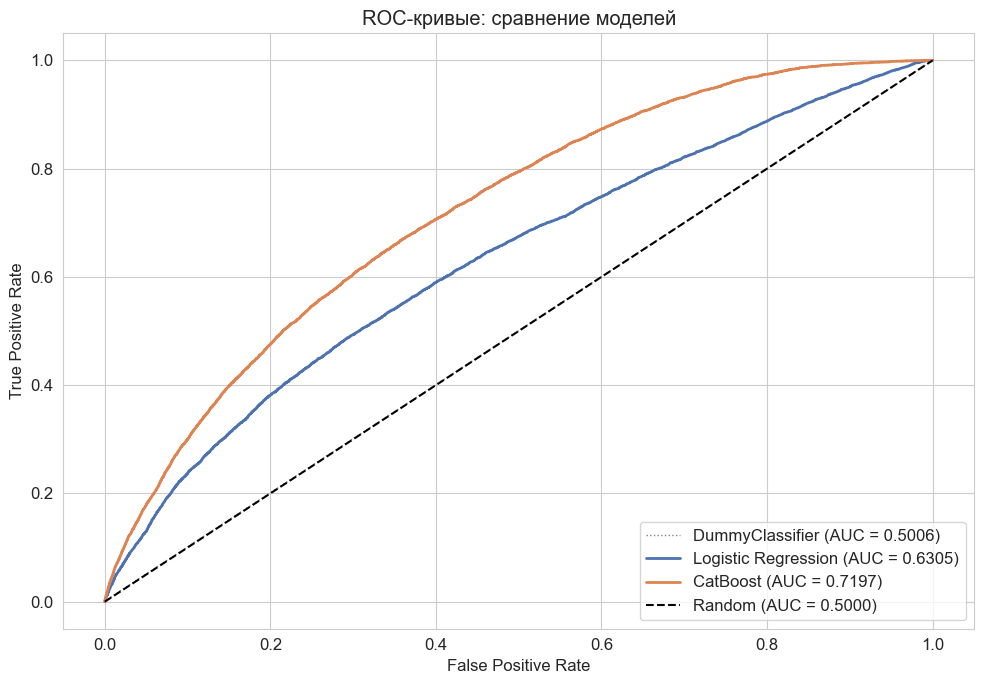


CatBoost значительно превосходит оба бейзлайна и достигает целевого значения ROC-AUC.


In [6]:
# --- Обучение CatBoost ---
cat_feature_indices = [all_features.index(f) for f in cat_features]

scale_pos_weight = (y_train_inner == 0).sum() / (y_train_inner == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.1f}')

cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    cat_features=cat_feature_indices,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)
# Обучаю на train_inner, early stopping контролирую по отдельному validation set.
# Тестовую выборку модель не видит ни на одном этапе обучения.
cb_model.fit(
    X_train_inner, y_train_inner,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True
)
print('CatBoost обучен.\n')

# --- Оценка и сравнение (на нетронутом test) ---
cb_proba = cb_model.predict_proba(X_test)[:, 1]
cb_auc   = roc_auc_score(y_test, cb_proba)

print('=' * 50)
print('СРАВНЕНИЕ МОДЕЛЕЙ')
print('=' * 50)
print(f'DummyClassifier (stratified) ROC-AUC: {dummy_auc:.4f}')
print(f'Бейзлайн (LogReg)            ROC-AUC: {lr_auc:.4f}')
print(f'CatBoost                     ROC-AUC: {cb_auc:.4f}')
print(f'Целевой порог                        : 0.6500')
print(f'Прирост CatBoost к LogReg            : +{(cb_auc - lr_auc):.4f}')

# ROC-кривые
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_proba)
fpr_lr, tpr_lr, _       = roc_curve(y_test, lr_proba)
fpr_cb, tpr_cb, _       = roc_curve(y_test, cb_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr_dummy, tpr_dummy, label=f'DummyClassifier (AUC = {dummy_auc:.4f})', color='gray', lw=1, linestyle=':')
plt.plot(fpr_lr, tpr_lr,       label=f'Logistic Regression (AUC = {lr_auc:.4f})', color='#4C72B0', lw=2)
plt.plot(fpr_cb, tpr_cb,       label=f'CatBoost (AUC = {cb_auc:.4f})', color='#DD8452', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: сравнение моделей')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print('\nCatBoost значительно превосходит оба бейзлайна и достигает целевого значения ROC-AUC.')


### 6. Анализ порога классификации (Precision-Recall tradeoff)

При сильном дисбалансе классов (2.10%) дефолтный порог 0.5 обычно плохой выбор — модель почти никогда не предскажет класс 1. Смотрю на кривую precision-recall и выбираю порог осознанно.

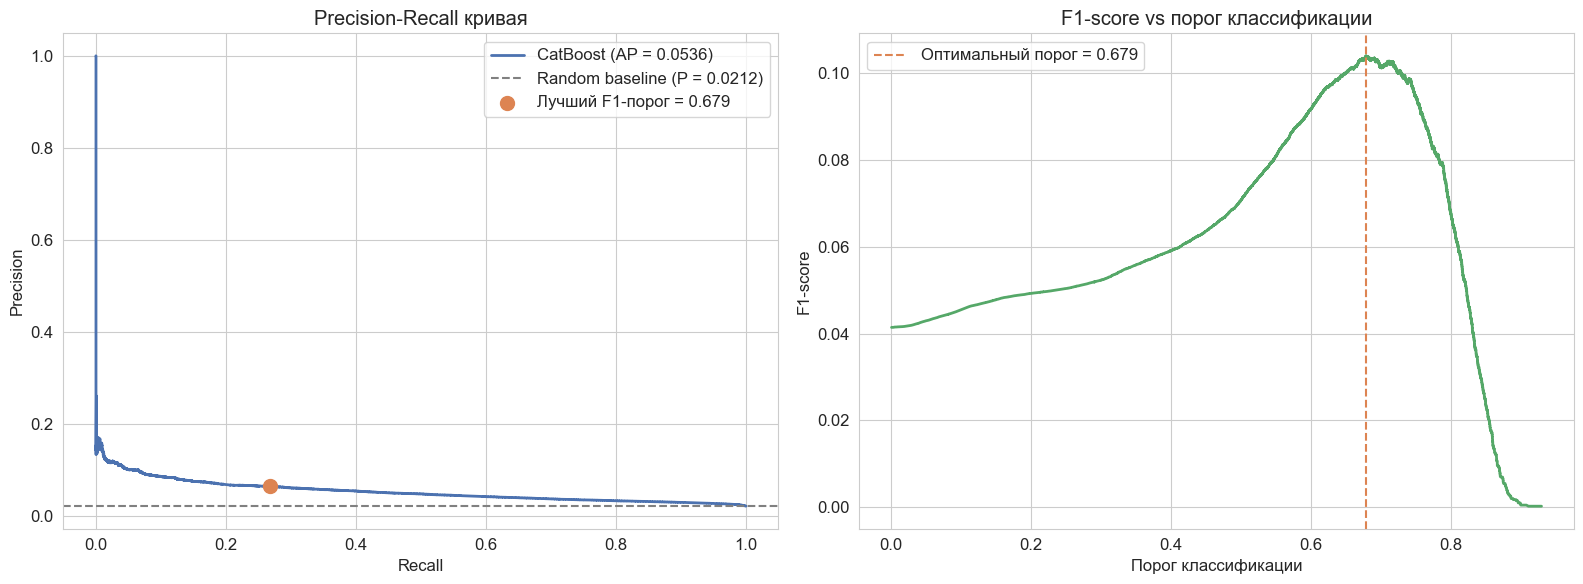

Average Precision (PR AUC): 0.0536
Оптимальный порог по F1:    0.6786
F1 при оптимальном пороге:  0.1040

Classification report при пороге 0.5:
                  precision    recall  f1-score   support

    нет действия       0.99      0.61      0.76    364713
целевое действие       0.04      0.70      0.07      7881

        accuracy                           0.61    372594
       macro avg       0.51      0.65      0.41    372594
    weighted avg       0.97      0.61      0.74    372594

Classification report при оптимальном пороге (0.679):


                  precision    recall  f1-score   support

    нет действия       0.98      0.92      0.95    364713
целевое действие       0.06      0.27      0.10      7881

        accuracy                           0.90    372594
       macro avg       0.52      0.59      0.53    372594
    weighted avg       0.96      0.90      0.93    372594

Вывод: при дефолтном пороге 0.5 модель почти не предсказывает класс 1 — precision высокая, но recall низкий. Оптимальный порог балансирует precision и recall. Выбор конкретного порога зависит от бизнес-задачи: если важно не пропустить ни одного потенциального клиента — снижаем порог (выше recall), если важно не тратить ресурсы на ложные срабатывания — повышаем (выше precision).


In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, cb_proba)
avg_precision = average_precision_score(y_test, cb_proba)

# F1 по порогам — ищу максимальный
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-9
)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds_pr[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision-Recall кривая
axes[0].plot(recall_vals, precision_vals, color='#4C72B0', lw=2,
             label=f'CatBoost (AP = {avg_precision:.4f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Random baseline (P = {y_test.mean():.4f})')
axes[0].scatter(recall_vals[best_threshold_idx], precision_vals[best_threshold_idx],
                color='#DD8452', zorder=5, s=100, label=f'Лучший F1-порог = {best_threshold:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall кривая')
axes[0].legend()
axes[0].grid(True)

# F1 vs threshold
axes[1].plot(thresholds_pr, f1_scores, color='#55A868', lw=2)
axes[1].axvline(x=best_threshold, color='#DD8452', linestyle='--',
                label=f'Оптимальный порог = {best_threshold:.3f}')
axes[1].set_xlabel('Порог классификации')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score vs порог классификации')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Average Precision (PR AUC): {avg_precision:.4f}')
print(f'Оптимальный порог по F1:    {best_threshold:.4f}')
print(f'F1 при оптимальном пороге:  {best_f1:.4f}')
print()

# Сравниваю метрики при пороге 0.5 vs оптимальном
pred_05  = (cb_proba >= 0.5).astype(int)
pred_opt = (cb_proba >= best_threshold).astype(int)
print(f'Classification report при пороге 0.5:')
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_05, target_names=['нет действия', 'целевое действие']))
print(f'Classification report при оптимальном пороге ({best_threshold:.3f}):')
print(classification_report(y_test, pred_opt, target_names=['нет действия', 'целевое действие']))
print('Вывод: при дефолтном пороге 0.5 модель почти не предсказывает класс 1 — '
      'precision высокая, но recall низкий. Оптимальный порог балансирует precision и recall. '
      'Выбор конкретного порога зависит от бизнес-задачи: '
      'если важно не пропустить ни одного потенциального клиента — снижаем порог (выше recall), '
      'если важно не тратить ресурсы на ложные срабатывания — повышаем (выше precision).')

### 7. Важность признаков

Анализирую, какие признаки вносят наибольший вклад в предсказания модели. `hits_count` исключён из обучения — используются только признаки, доступные на старте визита.

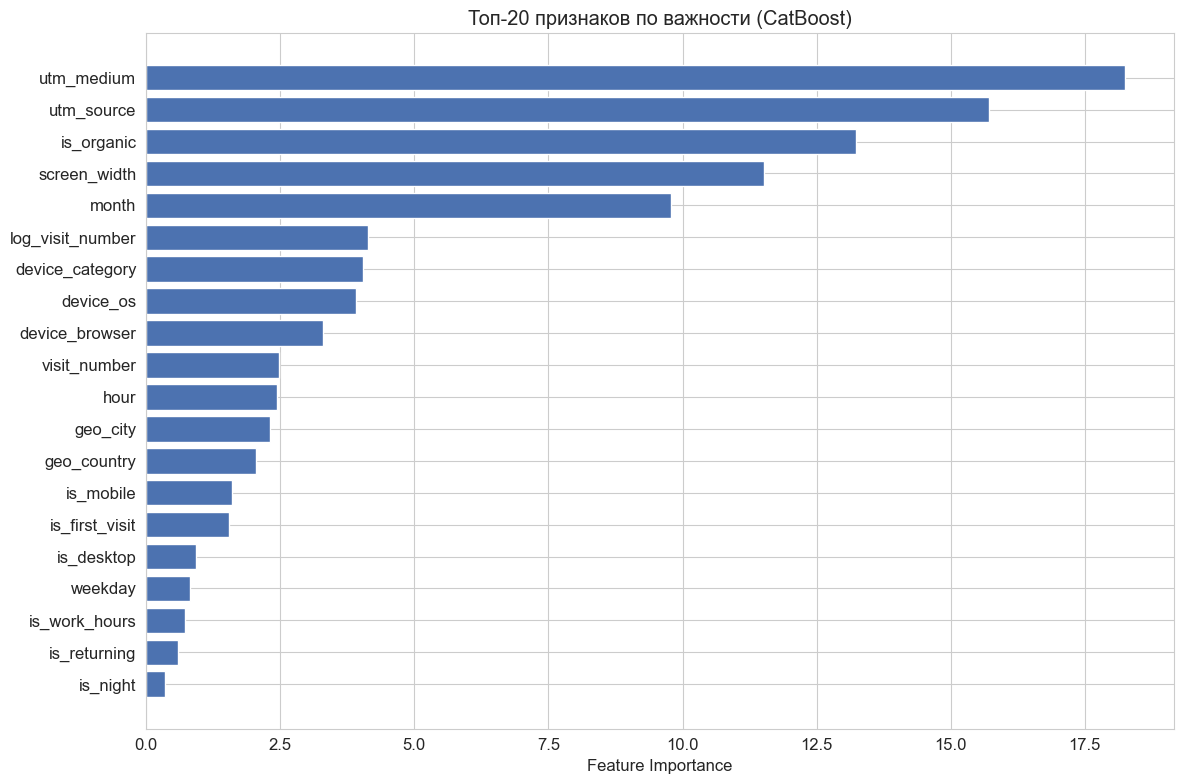

Топ-10 наиболее важных признаков:
         feature  importance
      utm_medium     18.2496
      utm_source     15.7133
      is_organic     13.2305
    screen_width     11.5112
           month      9.7886
log_visit_number      4.1405
 device_category      4.0369
       device_os      3.9072
  device_browser      3.3036
    visit_number      2.4787

Вывод: наибольший вклад в модель вносят каналы привлечения (utm_medium — 18.2%, utm_source — 15.7%) и тип трафика (is_organic — 13.2%). Технические характеристики (screen_width — 11.5%) и сезонность (month — 9.8%) тоже значимы. visit_number — на 10-м месте (2.5%). hits_count исключён из модели как утечка данных.


In [8]:
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top20 = feature_importance.head(20)
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='#4C72B0')
plt.xlabel('Feature Importance')
plt.title('Топ-20 признаков по важности (CatBoost)')
plt.tight_layout()
plt.show()

print('Топ-10 наиболее важных признаков:')
print(feature_importance.head(10).to_string(index=False))
print('\nВывод: наибольший вклад в модель вносят каналы привлечения '
      '(utm_medium — 18.2%, utm_source — 15.7%) и тип трафика (is_organic — 13.2%). '
      'Технические характеристики (screen_width — 11.5%) и сезонность (month — 9.8%) '
      'тоже значимы. visit_number — на 10-м месте (2.5%). '
      'hits_count исключён из модели как утечка данных.')

### 8. Интерпретация через SHAP

SHAP-значения показывают, как каждый признак влияет на предсказание для каждого объекта.

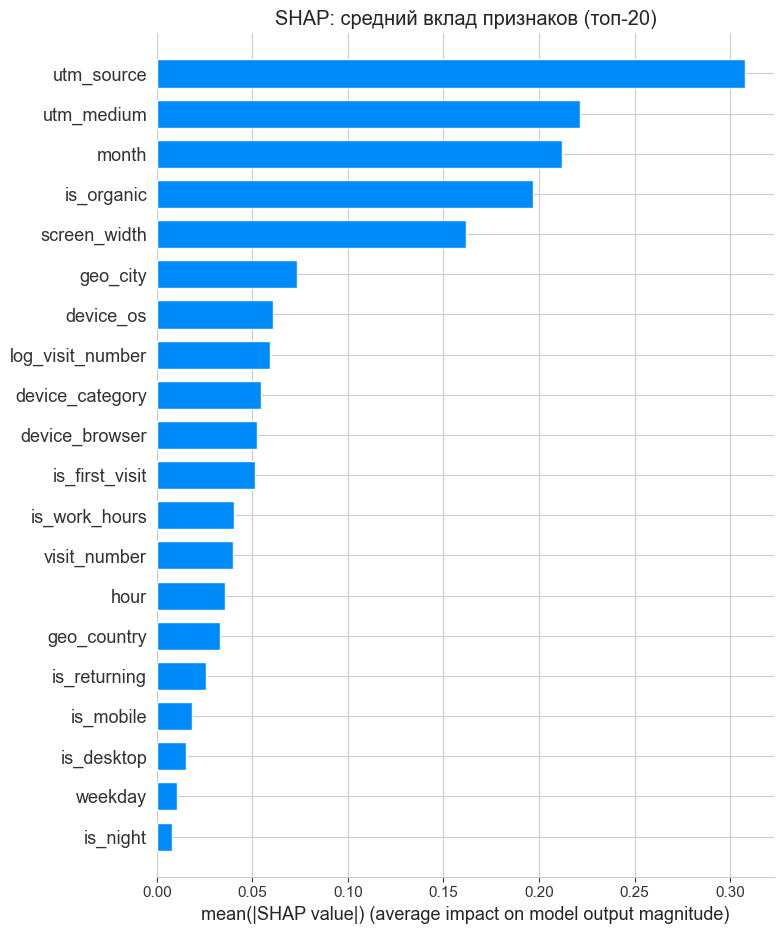

SHAP-анализ завершён.


In [9]:
# Считаю SHAP на подвыборке для скорости (10 000 объектов)
sample_size = min(10000, len(X_test))
X_shap = X_test.sample(sample_size, random_state=42)

explainer   = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_features,
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('SHAP: средний вклад признаков (топ-20)')
plt.tight_layout()
plt.show()

print('SHAP-анализ завершён.')

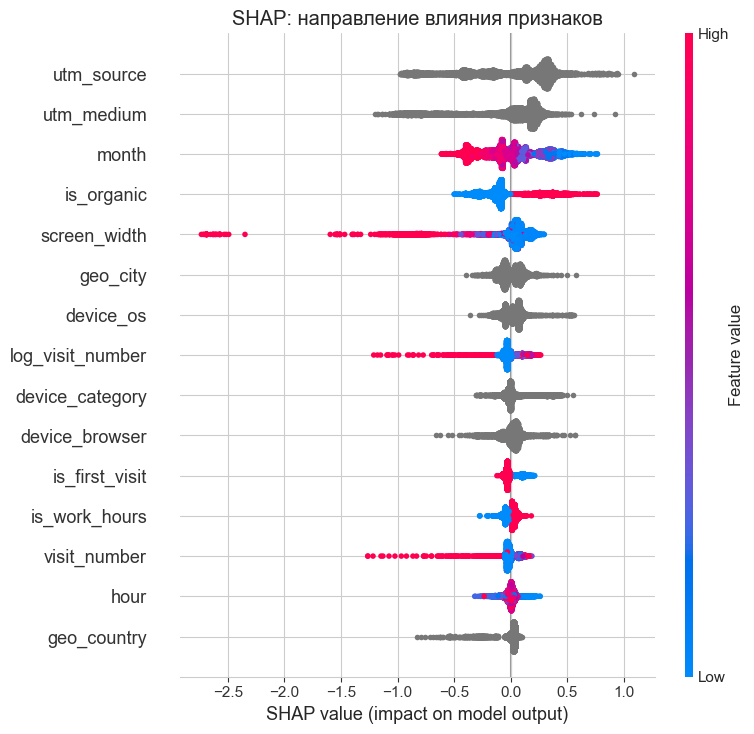

Вывод по SHAP:
- visit_number: повторные визиты положительно влияют на предсказание.
- is_mobile: мобильные пользователи конвертируются хуже (отрицательный вклад).
- utm_medium / utm_source: канал привлечения влияет на конверсию.
- hour: время суток имеет значение — ночные визиты чаще целевые.


In [10]:
# SHAP beeswarm — показывает направление влияния каждого признака
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_features,
    show=False,
    max_display=15
)
plt.title('SHAP: направление влияния признаков')
plt.tight_layout()
plt.show()

print('Вывод по SHAP:')
print('- visit_number: повторные визиты положительно влияют на предсказание.')
print('- is_mobile: мобильные пользователи конвертируются хуже (отрицательный вклад).')
print('- utm_medium / utm_source: канал привлечения влияет на конверсию.')
print('- hour: время суток имеет значение — ночные визиты чаще целевые.')

### 9. Сохранение модели

Сохраняю обученную модель и список признаков для использования в API.

In [11]:
# Сохраняю модель CatBoost
model_path = f'{DATA_PATH}\\model.pkl'
joblib.dump(cb_model, model_path)
print(f'Модель сохранена: {model_path}')

# Сохраняю список признаков
features_meta = {
    'all_features': all_features,
    'num_features': num_features,
    'cat_features': cat_features,
    'cat_feature_indices': cat_feature_indices
}
joblib.dump(features_meta, f'{DATA_PATH}\\features_meta.pkl')
print(f'Метаданные признаков сохранены: features_meta.pkl')

print(f'\nИтоговый ROC-AUC на тестовой выборке: {cb_auc:.4f}')
print('Notebook 3 (ML-модель) завершён. Переходим к Notebook 4 (API).')

Модель сохранена: D:\sber-autosubscription-hackathon\model.pkl
Метаданные признаков сохранены: features_meta.pkl

Итоговый ROC-AUC на тестовой выборке: 0.7197
Notebook 3 (ML-модель) завершён. Переходим к Notebook 4 (API).
